In [40]:
# -------------------------------
# NOTEBOOK 1: CANNY+LSD LINE DETECTION
# -------------------------------
# Cel: Wykrycie linii z ostatniego pliku adaptive_cleaned_*.jpg
# Wejście: adaptive_cleaned_*.jpg z notebooka 0
# Wyjście: JSON z liniami + wizualizacja

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime

print("✓ Libraries loaded")

✓ Libraries loaded


In [41]:
# -------------------------------
# PATHS CONFIGURATION
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"

INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

print(f"INTERMEDIATE_DIR: {INTERMEDIATE_DIR}")

INTERMEDIATE_DIR: C:\python\Intelligent_Sketch2CAD\intermediate_data


Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Image shape: (2022, 1152)
Mean pixel value: 251.2
✓ Polarity OK: white background + black lines


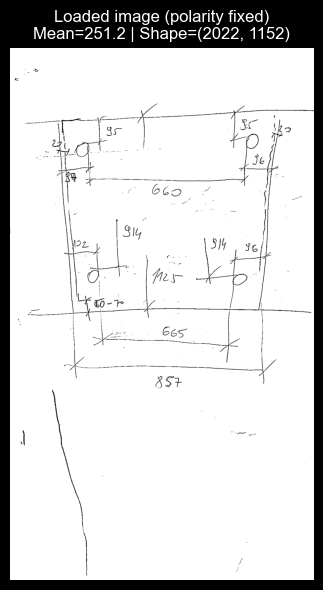

✓ Image loaded and polarity verified


In [48]:
# -------------------------------
# LOAD LATEST adaptive_cleaned IMAGE + FIX POLARITY
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No adaptive_cleaned_*.jpg found in {INTERMEDIATE_DIR}")

latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
if len(image.shape) == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray = image.copy()

print(f"Image shape: {gray.shape}")

# --- FIX POLARITY: zawsze chcemy białe tło + czarne linie ---
mean_val = np.mean(gray)
print(f"Mean pixel value: {mean_val:.1f}")
if mean_val < 128:
    gray = cv2.bitwise_not(gray)
    print("⚠️  Image was INVERTED (dark bg) → corrected to white bg + black lines")
else:
    print("✓ Polarity OK: white background + black lines")

# Podgląd po korekcji
plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap='gray')
plt.title(f"Loaded image (polarity fixed)\nMean={mean_val:.1f} | Shape={gray.shape}")
plt.axis('off')
plt.tight_layout()
plt.show()

print("✓ Image loaded and polarity verified")

In [49]:
# -------------------------------
# LINE DETECTION: STANDARD LSD (best method from your benchmark)
# -------------------------------
MIN_LINE_LENGTH = 5  # px — minimalna długość linii

print("--- STANDARD LSD (on grayscale) ---")

# Standard LSD - default parameters (as in your working script)
lsd = cv2.createLineSegmentDetector(0)

lines_raw = lsd.detect(gray)[0]

detected_lines = []
if lines_raw is not None:
    for line in lines_raw:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        if length >= MIN_LINE_LENGTH:
            detected_lines.append([int(x1), int(y1), int(x2), int(y2)])

print(f"Standard LSD detected: {len(detected_lines)} lines (>= {MIN_LINE_LENGTH}px)")
method_used = f"Standard LSD ({len(detected_lines)} lines)"

--- STANDARD LSD (on grayscale) ---
Standard LSD detected: 827 lines (>= 5px)


In [51]:
# -------------------------------
# LINE REGRESSION + ANGLE SNAPPING
# -------------------------------
import numpy as np
from sklearn.linear_model import RANSACRegressor

def fit_line_with_angle_snapping(points, target_angle=None, angle_threshold=15):
    """
    Dopasowuje prostą do punktów i zaokrągla kąt do 0/45/90 stopni
    """
    x = np.array([p[0] for p in points]).reshape(-1, 1)
    y = np.array([p[1] for p in points])

    if len(points) < 2:
        return None

    # RANSAC do znalezienia najlepszej prostej
    ransac = RANSACRegressor(random_state=42)
    ransac.fit(x, y)

    slope = ransac.estimator_.coef_[0]
    intercept = ransac.estimator_.intercept_
    angle = np.degrees(np.arctan(slope))

    # Określ docelowy kąt
    if target_angle is None:
        abs_angle = abs(angle)
        if abs_angle < angle_threshold or abs_angle > 180 - angle_threshold:
            target_angle = 0  # pozioma
        elif abs(abs_angle - 45) < angle_threshold:
            target_angle = 45  # skośna
        elif abs(abs_angle - 90) < angle_threshold:
            target_angle = 90  # pionowa
        else:
            target_angle = angle  # pozostaw oryginalny

    # Dopasuj prostą o docelowym kącie
    if target_angle == 0:  # pozioma
        slope = 0
        intercept = np.median(y)
        x_min, x_max = min(x)[0], max(x)[0]
        y_val = intercept
        return [int(x_min), int(y_val), int(x_max), int(y_val)]

    elif target_angle == 90:  # pionowa
        x_val = np.median(x)
        y_min, y_max = min(y), max(y)
        return [int(x_val), int(y_min), int(x_val), int(y_max)]

    elif target_angle == 45:  # skośna 45 stopni
        # Przelicz dla kąta 45 stopni
        slope = 1 if angle > 0 else -1
        # Znajdź najlepsze przesunięcie
        offsets = [p[1] - slope * p[0] for p in points]
        intercept = np.median(offsets)

        x_min, x_max = min(x)[0], max(x)[0]
        y_min = slope * x_min + intercept
        y_max = slope * x_max + intercept
        return [int(x_min), int(y_min), int(x_max), int(y_max)]

    else:
        # Pozostaw oryginalny kąt
        x_min, x_max = min(x)[0], max(x)[0]
        y_min = slope * x_min + intercept
        y_max = slope * x_max + intercept
        return [int(x_min), int(y_min), int(x_max), int(y_max)]

def group_and_refine_lines(lines, angle_threshold=15, distance_threshold=25):
    """
    Grupuje linie według kąta i pozycji, następnie dopasowuje idealną prostą
    """
    if len(lines) < 2:
        return lines

    # Klasyfikacja wstępna
    horizontal = []
    vertical = []
    diagonal = []
    other = []

    for line in lines:
        x1, y1, x2, y2 = line
        dx = x2 - x1
        dy = y2 - y1

        if dx == 0:
            angle = 90
        else:
            angle = abs(np.degrees(np.arctan2(dy, dx)))

        if angle < angle_threshold or angle > 180 - angle_threshold:
            horizontal.append(line)
        elif abs(angle - 90) < angle_threshold:
            vertical.append(line)
        elif abs(angle - 45) < angle_threshold or abs(angle - 135) < angle_threshold:
            diagonal.append(line)
        else:
            other.append(line)

    # Grupowanie i regresja dla poziomych
    refined = []

    # Poziome grupuj po Y
    horizontal_groups = []
    used = [False] * len(horizontal)

    for i, line1 in enumerate(horizontal):
        if used[i]:
            continue

        _, y1, _, y2 = line1
        y_avg = (y1 + y2) // 2

        group_points = [(line1[0], line1[1]), (line1[2], line1[3])]

        for j, line2 in enumerate(horizontal):
            if not used[j] and i != j:
                _, yy1, _, yy2 = line2
                yy_avg = (yy1 + yy2) // 2
                if abs(y_avg - yy_avg) < distance_threshold:
                    group_points.append((line2[0], line2[1]))
                    group_points.append((line2[2], line2[3]))
                    used[j] = True

        # Dopasuj idealną poziomą
        xs = [p[0] for p in group_points]
        ys = [p[1] for p in group_points]
        y_final = int(np.median(ys))
        x_min, x_max = min(xs), max(xs)
        refined.append([x_min, y_final, x_max, y_final])
        used[i] = True

    # Podobnie dla pionowych (grupuj po X)
    used = [False] * len(vertical)
    for i, line1 in enumerate(vertical):
        if used[i]:
            continue

        x1, _, x2, _ = line1
        x_avg = (x1 + x2) // 2

        group_points = [(line1[0], line1[1]), (line1[2], line1[3])]

        for j, line2 in enumerate(vertical):
            if not used[j] and i != j:
                xx1, _, xx2, _ = line2
                xx_avg = (xx1 + xx2) // 2
                if abs(x_avg - xx_avg) < distance_threshold:
                    group_points.append((line2[0], line2[1]))
                    group_points.append((line2[2], line2[3]))
                    used[j] = True

        xs = [p[0] for p in group_points]
        ys = [p[1] for p in group_points]
        x_final = int(np.median(xs))
        y_min, y_max = min(ys), max(ys)
        refined.append([x_final, y_min, x_final, y_max])
        used[i] = True

    # Dla diagonalnych i innych dodaj jak są
    for line in diagonal + other:
        refined.append(line)

    return refined

# Zastosuj
print(f"Before refinement: {len(detected_lines)} segments")
refined_lines = group_and_refine_lines(detected_lines, angle_threshold=15, distance_threshold=25)
print(f"After refinement: {len(refined_lines)} segments")

Before refinement: 827 segments
After refinement: 336 segments


In [52]:
# -------------------------------
# FILTER + CLASSIFY LINES
# 724 linii to dużo — zawiera:
# ├── ~4 linie głównego prostokąta (obiekt)
# ├── ~linie wymiarowe (krótsze, z tickami)
# ├── linie cyfr/tekstu (bardzo krótkie)
# └── szum
#
# Strategia filtrowania:
#   - oblicz długości wszystkich linii
#   - podziel na kategorie wg progu długości
#   - główne linie obiektu = najdłuższe (top percentile)
#   - linie wymiarowe = średnie
#   - szum/tekst = bardzo krótkie → odrzuć
# -------------------------------

def line_length(line):
    x1, y1, x2, y2 = line
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

lengths = np.array([line_length(l) for l in detected_lines])

if len(lengths) > 0:
    p25 = np.percentile(lengths, 25)
    p50 = np.percentile(lengths, 50)
    p75 = np.percentile(lengths, 75)
    p90 = np.percentile(lengths, 90)
    print(f"Line length stats:")
    print(f"  min={lengths.min():.1f}  p25={p25:.1f}  p50={p50:.1f}  "
          f"p75={p75:.1f}  p90={p90:.1f}  max={lengths.max():.1f}")

# Progi kategoryzacji
NOISE_MAX_LEN    = max(p25, 10)   # < p25 → szum/tekst → odrzuć
DIM_MAX_LEN      = p75            # p25–p75 → linie wymiarowe
# >= p75 → kandydaci na główne linie obiektu

object_lines = []
dimension_lines = []
noise_lines = []

for line in detected_lines:
    ln = line_length(line)
    if ln < NOISE_MAX_LEN:
        noise_lines.append(line)
    elif ln < DIM_MAX_LEN:
        dimension_lines.append(line)
    else:
        object_lines.append(line)

print(f"\nAfter length-based filtering:")
print(f"  Object lines  (>= {DIM_MAX_LEN:.1f}px) : {len(object_lines)}")
print(f"  Dimension lines ({NOISE_MAX_LEN:.1f}–{DIM_MAX_LEN:.1f}px): {len(dimension_lines)}")
print(f"  Noise/text  (< {NOISE_MAX_LEN:.1f}px) : {len(noise_lines)}  ← discarded")

# Połącz object + dimension jako "meaningful lines" do dalszej analizy
meaningful_lines = object_lines + dimension_lines
print(f"  Meaningful total: {len(meaningful_lines)}")

Line length stats:
  min=6.0  p25=12.0  p50=18.1  p75=34.4  p90=69.6  max=355.1

After length-based filtering:
  Object lines  (>= 34.4px) : 207
  Dimension lines (12.0–34.4px): 425
  Noise/text  (< 12.0px) : 195  ← discarded
  Meaningful total: 632


In [53]:
# -------------------------------
# STEP 4: MERGE COLLINEAR SEGMENTS
# -------------------------------
def merge_collinear_segments(lines, angle_threshold=10, distance_threshold=25):
    """
    Łączy segmenty które leżą na tej samej linii prostej i są blisko siebie
    """
    if len(lines) < 2:
        return lines

    merged = []
    used = [False] * len(lines)

    for i, line1 in enumerate(lines):
        if used[i]:
            continue

        x1, y1, x2, y2 = line1
        dx1 = x2 - x1
        dy1 = y2 - y1
        angle1 = np.degrees(np.arctan2(dy1, dx1)) % 180

        group = [line1]

        for j, line2 in enumerate(lines):
            if i != j and not used[j]:
                x3, y3, x4, y4 = line2
                dx2 = x4 - x3
                dy2 = y4 - y3
                angle2 = np.degrees(np.arctan2(dy2, dx2)) % 180

                # Sprawdź czy kąty podobne
                angle_diff = min(abs(angle1 - angle2), 180 - abs(angle1 - angle2))
                if angle_diff > angle_threshold:
                    continue

                # Sprawdź odległość między końcami
                endpoints = [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]
                min_dist = min(
                    np.sqrt((x2-x3)**2 + (y2-y3)**2),
                    np.sqrt((x1-x4)**2 + (y1-y4)**2)
                )

                if min_dist < distance_threshold:
                    group.append(line2)
                    used[j] = True

        # Połącz wszystkie punkty w grupie
        all_x = []
        all_y = []
        for line in group:
            all_x.extend([line[0], line[2]])
            all_y.extend([line[1], line[3]])

        merged_line = [min(all_x), min(all_y), max(all_x), max(all_y)]
        merged.append(merged_line)
        used[i] = True

    return merged

# Zastosuj łączenie
print(f"Before merge: {len(detected_lines)} segments")
detected_lines = merge_collinear_segments(detected_lines, angle_threshold=10, distance_threshold=25)
print(f"After merge: {len(detected_lines)} segments")

Before merge: 827 segments
After merge: 362 segments


In [54]:
# -------------------------------
# CLASSIFY: Horizontal vs Vertical
# (operujemy na meaningful_lines, nie na całym detected_lines)
# -------------------------------
horizontal = []
vertical = []
other = []

for line in meaningful_lines:
    x1, y1, x2, y2 = line
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    if dx > dy * 2:  # mostly horizontal
        horizontal.append(line)
    elif dy > dx * 2:  # mostly vertical
        vertical.append(line)
    else:
        other.append(line)

print(f"\nClassification (meaningful lines only):")
print(f"  Horizontal: {len(horizontal)}")
print(f"  Vertical: {len(vertical)}")
print(f"  Other (diagonal): {len(other)}")


Classification (meaningful lines only):
  Horizontal: 244
  Vertical: 268
  Other (diagonal): 120


In [55]:
# -------------------------------
# LINE REGRESSION + ANGLE SNAPPING
# -------------------------------
import numpy as np
from sklearn.linear_model import RANSACRegressor

def fit_line_with_angle_snapping(points, target_angle=None, angle_threshold=15):
    """
    Dopasowuje prostą do punktów i zaokrągla kąt do 0/45/90 stopni
    """
    x = np.array([p[0] for p in points]).reshape(-1, 1)
    y = np.array([p[1] for p in points])

    if len(points) < 2:
        return None

    # RANSAC do znalezienia najlepszej prostej
    ransac = RANSACRegressor(random_state=42)
    ransac.fit(x, y)

    slope = ransac.estimator_.coef_[0]
    intercept = ransac.estimator_.intercept_
    angle = np.degrees(np.arctan(slope))

    # Określ docelowy kąt
    if target_angle is None:
        abs_angle = abs(angle)
        if abs_angle < angle_threshold or abs_angle > 180 - angle_threshold:
            target_angle = 0  # pozioma
        elif abs(abs_angle - 45) < angle_threshold:
            target_angle = 45  # skośna
        elif abs(abs_angle - 90) < angle_threshold:
            target_angle = 90  # pionowa
        else:
            target_angle = angle  # pozostaw oryginalny

    # Dopasuj prostą o docelowym kącie
    if target_angle == 0:  # pozioma
        slope = 0
        intercept = np.median(y)
        x_min, x_max = min(x)[0], max(x)[0]
        y_val = intercept
        return [int(x_min), int(y_val), int(x_max), int(y_val)]

    elif target_angle == 90:  # pionowa
        x_val = np.median(x)
        y_min, y_max = min(y), max(y)
        return [int(x_val), int(y_min), int(x_val), int(y_max)]

    elif target_angle == 45:  # skośna 45 stopni
        # Przelicz dla kąta 45 stopni
        slope = 1 if angle > 0 else -1
        # Znajdź najlepsze przesunięcie
        offsets = [p[1] - slope * p[0] for p in points]
        intercept = np.median(offsets)

        x_min, x_max = min(x)[0], max(x)[0]
        y_min = slope * x_min + intercept
        y_max = slope * x_max + intercept
        return [int(x_min), int(y_min), int(x_max), int(y_max)]

    else:
        # Pozostaw oryginalny kąt
        x_min, x_max = min(x)[0], max(x)[0]
        y_min = slope * x_min + intercept
        y_max = slope * x_max + intercept
        return [int(x_min), int(y_min), int(x_max), int(y_max)]

def group_and_refine_lines(lines, angle_threshold=15, distance_threshold=25):
    """
    Grupuje linie według kąta i pozycji, następnie dopasowuje idealną prostą
    """
    if len(lines) < 2:
        return lines

    # Klasyfikacja wstępna
    horizontal = []
    vertical = []
    diagonal = []
    other = []

    for line in lines:
        x1, y1, x2, y2 = line
        dx = x2 - x1
        dy = y2 - y1

        if dx == 0:
            angle = 90
        else:
            angle = abs(np.degrees(np.arctan2(dy, dx)))

        if angle < angle_threshold or angle > 180 - angle_threshold:
            horizontal.append(line)
        elif abs(angle - 90) < angle_threshold:
            vertical.append(line)
        elif abs(angle - 45) < angle_threshold or abs(angle - 135) < angle_threshold:
            diagonal.append(line)
        else:
            other.append(line)

    # Grupowanie i regresja dla poziomych
    refined = []

    # Poziome grupuj po Y
    horizontal_groups = []
    used = [False] * len(horizontal)

    for i, line1 in enumerate(horizontal):
        if used[i]:
            continue

        _, y1, _, y2 = line1
        y_avg = (y1 + y2) // 2

        group_points = [(line1[0], line1[1]), (line1[2], line1[3])]

        for j, line2 in enumerate(horizontal):
            if not used[j] and i != j:
                _, yy1, _, yy2 = line2
                yy_avg = (yy1 + yy2) // 2
                if abs(y_avg - yy_avg) < distance_threshold:
                    group_points.append((line2[0], line2[1]))
                    group_points.append((line2[2], line2[3]))
                    used[j] = True

        # Dopasuj idealną poziomą
        xs = [p[0] for p in group_points]
        ys = [p[1] for p in group_points]
        y_final = int(np.median(ys))
        x_min, x_max = min(xs), max(xs)
        refined.append([x_min, y_final, x_max, y_final])
        used[i] = True

    # Podobnie dla pionowych (grupuj po X)
    used = [False] * len(vertical)
    for i, line1 in enumerate(vertical):
        if used[i]:
            continue

        x1, _, x2, _ = line1
        x_avg = (x1 + x2) // 2

        group_points = [(line1[0], line1[1]), (line1[2], line1[3])]

        for j, line2 in enumerate(vertical):
            if not used[j] and i != j:
                xx1, _, xx2, _ = line2
                xx_avg = (xx1 + xx2) // 2
                if abs(x_avg - xx_avg) < distance_threshold:
                    group_points.append((line2[0], line2[1]))
                    group_points.append((line2[2], line2[3]))
                    used[j] = True

        xs = [p[0] for p in group_points]
        ys = [p[1] for p in group_points]
        x_final = int(np.median(xs))
        y_min, y_max = min(ys), max(ys)
        refined.append([x_final, y_min, x_final, y_max])
        used[i] = True

    # Dla diagonalnych i innych dodaj jak są
    for line in diagonal + other:
        refined.append(line)

    return refined

# Zastosuj
print(f"Before refinement: {len(detected_lines)} segments")
refined_lines = group_and_refine_lines(detected_lines, angle_threshold=15, distance_threshold=25)
print(f"After refinement: {len(refined_lines)} segments")

Before refinement: 362 segments
After refinement: 221 segments


In [57]:
# -------------------------------
# DETECT CIRCLES (HoughCircles)
# -------------------------------
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                           param1=50, param2=30, minRadius=5, maxRadius=100)

if circles is not None:
    circles = np.round(circles[0, :]).astype(int)
    print(f"Detected {len(circles)} circles")
    # Dodaj do wyników

Detected 4 circles


In [59]:
# -------------------------------
# SIMPLE MERGE (tested, works)
# -------------------------------
def merge_lines_simple(lines, max_gap=30):
    """
    Łączy linie które są w jednej linii prostej i mają przerwę < max_gap
    """
    if len(lines) < 2:
        return lines

    # Sortuj linie według kąta
    lines_with_angle = []
    for line in lines:
        x1, y1, x2, y2 = line
        dx = x2 - x1
        dy = y2 - y1
        angle = np.degrees(np.arctan2(dy, dx)) % 180
        lines_with_angle.append((line, angle))

    # Sortuj po kącie
    lines_with_angle.sort(key=lambda x: x[1])

    merged = []
    used = [False] * len(lines)

    for i, (line1, angle1) in enumerate(lines_with_angle):
        if used[i]:
            continue

        group = [line1]

        for j, (line2, angle2) in enumerate(lines_with_angle):
            if i != j and not used[j]:
                # Sprawdź czy kąty podobne (różnica < 5 stopni)
                if abs(angle1 - angle2) > 5 and abs(angle1 - angle2) < 175:
                    continue

                # Sprawdź odległość między końcami
                x1, y1, x2, y2 = line1
                x3, y3, x4, y4 = line2

                dist = min(
                    np.sqrt((x2-x3)**2 + (y2-y3)**2),
                    np.sqrt((x1-x4)**2 + (y1-y4)**2)
                )

                if dist < max_gap:
                    group.append(line2)
                    used[j] = True

        # Połącz
        all_x = []
        all_y = []
        for line in group:
            all_x.extend([line[0], line[2]])
            all_y.extend([line[1], line[3]])

        merged.append([min(all_x), min(all_y), max(all_x), max(all_y)])
        used[i] = True

    return merged

# Zastosuj
print(f"Before merge: {len(detected_lines)}")
detected_lines = merge_lines_simple(detected_lines, max_gap=30)
print(f"After merge: {len(detected_lines)}")

Before merge: 362
After merge: 272


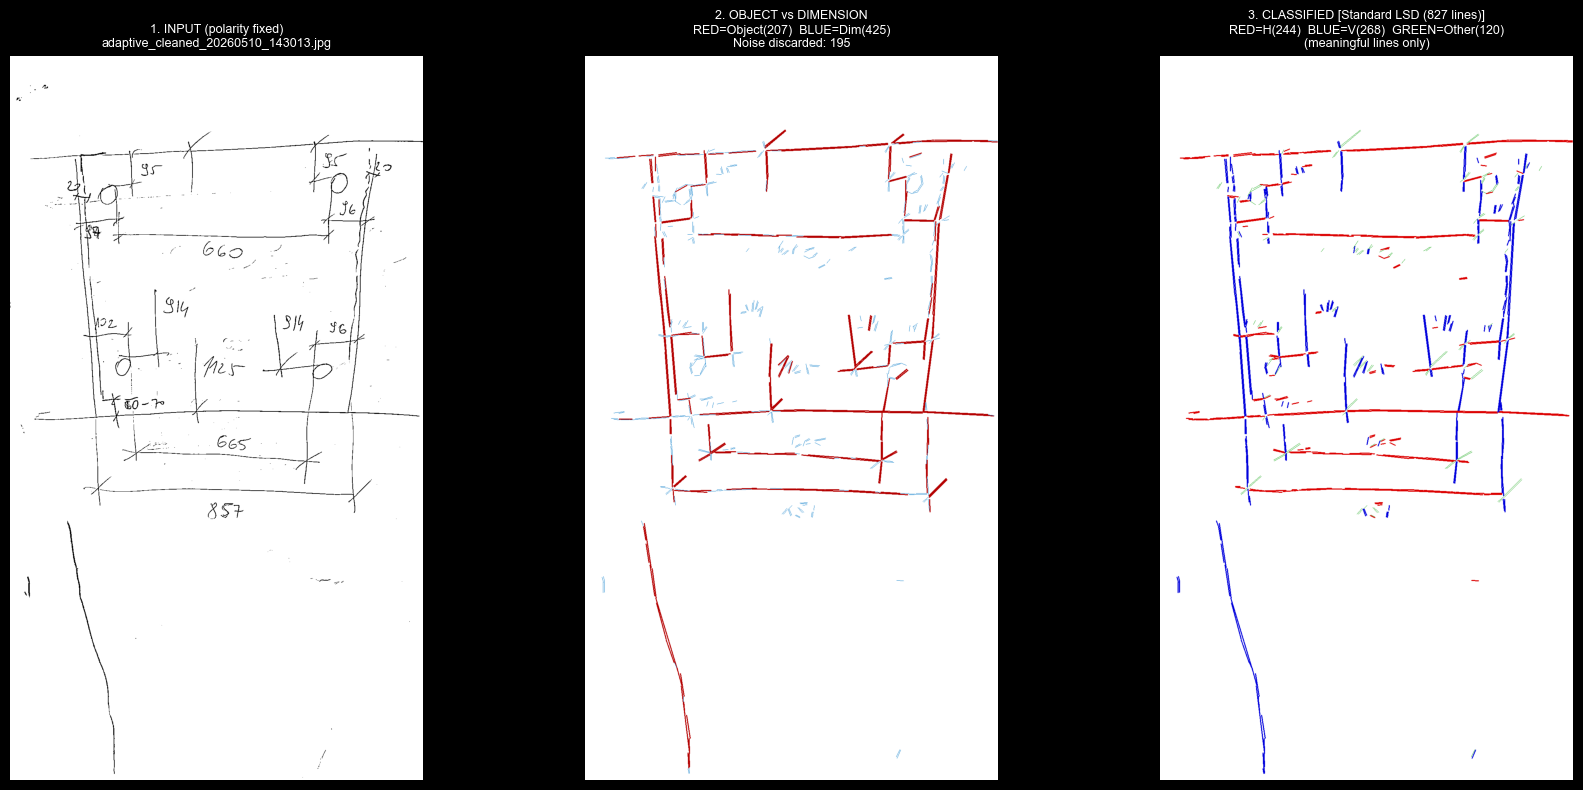


Summary:
  Object lines   : 207
  Dimension lines: 425
  Noise (discarded): 195
  Horizontal : 244
  Vertical   : 268
  Other      : 120
  TOTAL meaningful : 632


In [60]:
# -------------------------------
# VISUALIZATION — białe tło, kolorowe linie
# RED=Horizontal, BLUE=Vertical, GREEN=Other
# Dodatkowy panel: Object vs Dimension lines
# -------------------------------

# Rysuj NA BIAŁYM TLE (nie na szarości)
overlay = np.ones((gray.shape[0], gray.shape[1], 3), dtype=np.uint8) * 255

for line in horizontal:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), (220, 0, 0), 2)    # RED

for line in vertical:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), (0, 0, 220), 2)    # BLUE

for line in other:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), (0, 160, 0), 1)    # GREEN (thin)

# Dodatkowa wizualizacja: object vs dimension
overlay2 = np.ones((gray.shape[0], gray.shape[1], 3), dtype=np.uint8) * 255
for line in object_lines:
    x1, y1, x2, y2 = line
    cv2.line(overlay2, (x1, y1), (x2, y2), (180, 0, 0), 2)   # RED = object
for line in dimension_lines:
    x1, y1, x2, y2 = line
    cv2.line(overlay2, (x1, y1), (x2, y2), (0, 120, 200), 1) # BLUE = dimension

fig, axes = plt.subplots(1, 3, figsize=(18, 8))  # Changed from 1,4 to 1,3

axes[0].imshow(gray, cmap='gray')
axes[0].set_title(f"1. INPUT (polarity fixed)\n{Path(latest_file).name}", fontsize=9)
axes[0].axis("off")

axes[1].imshow(overlay2)
axes[1].set_title(
    f"2. OBJECT vs DIMENSION\n"
    f"RED=Object({len(object_lines)})  BLUE=Dim({len(dimension_lines)})\n"
    f"Noise discarded: {len(noise_lines)}",
    fontsize=9
)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(
    f"3. CLASSIFIED [{method_used}]\n"
    f"RED=H({len(horizontal)})  BLUE=V({len(vertical)})  GREEN=Other({len(other)})\n"
    f"(meaningful lines only)",
    fontsize=9
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Object lines   : {len(object_lines)}")
print(f"  Dimension lines: {len(dimension_lines)}")
print(f"  Noise (discarded): {len(noise_lines)}")
print(f"  Horizontal : {len(horizontal)}")
print(f"  Vertical   : {len(vertical)}")
print(f"  Other      : {len(other)}")
print(f"  TOTAL meaningful : {len(meaningful_lines)}")

In [ ]:
# -------------------------------
# SAVE RESULTS → dla notebook 2_geometry_extraction
# -------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

lines_data = {
    "timestamp": timestamp,
    "method_used": method_used,
    "source_image": str(latest_file),
    "image_shape": list(gray.shape),
    "total_lines_raw": len(detected_lines),
    "total_lines_meaningful": len(meaningful_lines),
    "object_line_count": len(object_lines),
    "dimension_line_count": len(dimension_lines),
    "noise_line_count": len(noise_lines),
    "horizontal_count": len(horizontal),
    "vertical_count": len(vertical),
    "other_count": len(other),
    "length_thresholds": {
        "noise_max": float(NOISE_MAX_LEN),
        "dimension_max": float(DIM_MAX_LEN)
    },
    "object_lines": object_lines,
    "dimension_lines": dimension_lines,
    "horizontal_lines": horizontal,
    "vertical_lines": vertical,
    "other_lines": other,
    "all_lines": detected_lines,
    "meaningful_lines": meaningful_lines
}

json_path = INTERMEDIATE_DIR / f"lines_nb1_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(lines_data, f, indent=2)

# Zapisz wizualizację (BGR dla cv2)
vis_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
vis_path = INTERMEDIATE_DIR / f"lines_vis_nb1_{timestamp}.jpg"
cv2.imwrite(str(vis_path), vis_bgr)

vis2_bgr = cv2.cvtColor(overlay2, cv2.COLOR_RGB2BGR)
vis2_path = INTERMEDIATE_DIR / f"lines_vis_nb1_objdim_{timestamp}.jpg"
cv2.imwrite(str(vis2_bgr), vis2_bgr)

print(f"\n✅ NOTEBOOK 1 DONE")
print(f"   JSON  → {json_path}")
print(f"   VIS   → {vis_path}")
print(f"   VIS2  → {vis2_path}")
print(f"\n   Object={len(object_lines)}  Dim={len(dimension_lines)}  Noise={len(noise_lines)}")
print(f"   H={len(horizontal)}  V={len(vertical)}  Other={len(other)}  Meaningful={len(meaningful_lines)}")
print(f"\n▶ Następny krok: 2_geometry_extraction.ipynb")

In [ ]:
# Wskaż bezpośrednią ścieżkę do tesseract.exe
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [ ]:
# Przeskaluj obraz 2x lub 3x przed OCR
scale = 3
h, w = gray.shape
scaled = cv2.resize(gray, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)

# Wykonaj OCR na przeskalowanym obrazie
custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789-'
ocr_result = pytesseract.image_to_string(scaled, config=custom_config)
numbers = re.findall(r'\d+(?:[-]\d+)?', ocr_result)
print(f"OCR po przeskalowaniu: {numbers}")

In [ ]:
# Po wykryciu linii (Twój obecny stan)
# Dodaj tę komórkę:

# -------------------------------
# STEP: EXTRACT DIMENSIONS (NUMBERS)
# -------------------------------
import pytesseract
import re

custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789-'

# OCR na oryginalnym obrazie (gray)
ocr_result = pytesseract.image_to_string(gray, config=custom_config)
numbers = re.findall(r'\d+(?:[-]\d+)?', ocr_result)

print(f"Znalezione wymiary: {numbers}")

# Mapuj na znane wymiary (na podstawie Twojego rysunku)
expected = {
    "height": None,      # 1125 lub 665
    "width": None,       # 857
    "hole_position": None,  # 914
    "small": [],         # 95, 102, 60-70
}

for n in numbers:
    if '-' in n:
        expected["range"] = n
    elif int(n) > 800:
        if expected["height"] is None:
            expected["height"] = int(n)
        else:
            expected["width"] = int(n)
    elif int(n) > 500:
        if expected["hole_position"] is None:
            expected["hole_position"] = int(n)
    else:
        expected["small"].append(int(n))

print(f"\nWymiary dla CAD:")
print(f"  Wysokość: {expected['height']}")
print(f"  Szerokość: {expected['width']}")
print(f"  Pozycja otworu: {expected['hole_position']}")
print(f"  Małe wymiary: {expected['small']}")
print(f"  Zakres: {expected.get('range', 'brak')}")